# Multi-Trace BLAS → GPU Kernel → Power Analysis

Same pipeline as `lib_call_kernel_power.ipynb`, but pooled across **multiple traces**.
Each trace must contain:

- `MPI Rank N_Master_thread_callgraph.csv` (CPU BLAS calls)
- `MPI Rank N_metrics.csv` (per-device energy counters)
- `HIP Context N_HIP[N:M]_callgraph.csv` (GPU kernel launches)

Add paths to `TRACE_PATHS` below — every trace is loaded, tagged, and pooled into unified
`df_cpu`, `df_gpu`, and `power_traces` structures. Figures either pool everything (for broad
statistics) or facet by trace (when per-trace comparison is informative).

In [1]:
# -- Setup --
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 160, 'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 9.5, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5, 'legend.fontsize': 8.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.6, 'grid.linewidth': 0.4,
})
BG = '#fafafa'

# ===== Traces to analyse =====
# Add as many paths as you have. Each entry: label -> path.
TRACE_PATHS = {
    'HPL':  './hpl-captured-params-HIP',
    'HPL-MxP':  './hpl-mxp-hip',
    'HPG-MxP':  './hpg-mxp-hip',
    # 'RunB': './some-other-hip-trace',
    # 'RunC': './yet-another',
}
TDP_THRESHOLD = 560   # MI250X TDP (W)
# ==============================

# MI250X topology: device id → pair of GCDs
DEVICE_TO_GCDS = {4: [0, 1], 2: [2, 3], 6: [4, 5], 0: [6, 7]}
GCD_TO_DEVICE  = {g: d for d, gs in DEVICE_TO_GCDS.items() for g in gs}

BLAS_ENTRY_POINTS = {
    # rocBLAS entry points
    'rocblas_dgemm', 'rocblas_dtrsm', 'rocblas_dgemv', 'rocblas_dtrsv',
    'rocblas_dsyrk', 'rocblas_dtrmm', 'rocblas_dger', 'rocblas_dscal',
    'rocblas_daxpy', 'rocblas_dcopy', 'rocblas_idamax',
    'rocblas_sgemm', 'rocblas_sgemv', 'rocblas_strsm', 'rocblas_strsv',
    'rocblas_gemm_ex',
    # rocSOLVER entry points
    'rocsolver_dgetrf', 'rocsolver_dgetrs',
    'rocsolver_strtri', 'rocsolver_dtrtri',
}

def shortname(n):
    p = n.find('(')
    base = n[:p] if p != -1 else n
    a = base.find('<')
    return (base[:a] if a != -1 else base).strip()

# Label helpers for GPU kernels
CIJK_RE = re.compile(r'^(Cijk_[A-Za-z]+_[A-Za-z]+)_[A-Z]+_MT(\d+x\d+x\d+)')

def gpu_label(name):
    """Compact identifier for a GPU kernel launch name."""
    m = CIJK_RE.match(name)
    if m:
        return f"{m.group(1)}_MT{m.group(2)}"
    s = re.sub(r'^void\s+', '', name)
    m = re.match(r'^rocsolver::(?:[\w]+::)*(\w+)', s)
    if m:
        return f"rocsolver::{m.group(1)}"
    m = re.match(r'^(HPLMXP_\w+)', s)
    if m:
        return m.group(1)
    m = re.match(r'^(rocblas_\w+)', s)
    if m:
        return m.group(1)
    m = re.match(r'^([a-zA-Z_][\w]*)[<(]', s)
    if m:
        return m.group(1)
    return s[:60].strip()

def gpu_family(label):
    l = label.lower()
    if label.startswith('Cijk_'):                                  return 'GEMM'
    if l.startswith('rocsolver::'):
        if 'getf2' in l or 'getrf' in l or 'getrs' in l:           return 'LU'
        if 'forward_sub' in l or 'backward_sub' in l:              return 'TRSM-kern'
        if 'trtri' in l:                                           return 'TRTRI'
        return 'rocSOLVER-util'
    if label.startswith('rocblas_trtri'):                          return 'TRTRI'
    if label.startswith('rocblas_trsm'):                           return 'TRSM-kern'
    if label.startswith('rocblas_copy'):                           return 'Copy'
    if 'gemv' in l:                                                return 'GEMV'
    if label.startswith('rocblas_trsv') or 'trsv_init' in l:       return 'TRSV'
    if label.startswith('rocblas_scal'):                           return 'SCAL'
    if 'axpy' in l:                                                return 'AXPY'
    if label.startswith('rocblas_'):                               return 'rocBLAS-util'
    if 'symgs' in l or 'forward_sweep' in l or 'backward_sweep' in l: return 'SYMGS'
    if 'spmv' in l:                                                return 'SpMV'
    if 'restrict' in l or 'prolong' in l:                          return 'MG'
    if 'jpl' in l or 'coloring' in l:                              return 'Coloring'
    if 'to_ell' in l or 'perm_cols' in l or 'extract_diag' in l:   return 'SparseSetup'
    if 'lacpy' in l or 'latcpy' in l:                              return 'LACPY'
    if 'norminf' in l or 'norm1' in l or l.startswith('norm_'):    return 'Norm'
    if l == 'sum_double' or l.startswith('sum_'):                  return 'Reduction'
    if 'randmat' in l or 'hpl_set' in l or 'identity_kernel' in l or 'iota' in l or 'setzero' in l: return 'Init'
    if 'transpose' in l or 'ptranspose' in l:                      return 'Transpose'
    if 'paydx' in l or 'pcopy' in l:                               return 'Util'
    if label.startswith('dlaswp'):                                 return 'LASWP'
    if label.startswith('dlatcpy') or label.startswith('dlacpy'):  return 'LACPY'
    if label.startswith('hpl_randmat'):                            return 'Init'
    if 'rocrand' in l:                                             return 'RNG'
    return 'Other'

FAMILY_PALETTE = {
    'GEMM':          '#2d6a4f',
    'LU':            '#8e44ad',
    'TRTRI':         '#d90429',
    'TRSM-kern':     '#e07a3a',
    'Copy':          '#9b5de5',
    'GEMV':          '#06a77d',
    'TRSV':          '#3a86ff',
    'SCAL':          '#8d99ae',
    'AXPY':          '#b5838d',
    'LASWP':         '#ffb703',
    'LACPY':         '#f4a261',
    'Norm':          '#5a189a',
    'Reduction':     '#ff006e',
    'SYMGS':         '#457b9d',
    'SpMV':          '#2a9d8f',
    'MG':            '#e63946',
    'Coloring':      '#fb8500',
    'SparseSetup':   '#a8dadc',
    'Init':          '#ffb4a2',
    'Transpose':     '#bdb2ff',
    'Util':          '#cdb4db',
    'rocSOLVER-util':'#ffafcc',
    'rocBLAS-util':  '#b5e48c',
    'RNG':           '#00b4d8',
    'Other':         '#999999',
}

# Per-trace plotting palette
TRACE_PALETTE = dict(zip(TRACE_PATHS.keys(),
    ['#2d6a4f', '#e07a3a', '#457b9d', '#9b5de5', '#d90429', '#06a77d', '#ffb703', '#8d99ae']))
print(f"Will load {len(TRACE_PATHS)} trace(s): {list(TRACE_PATHS)}")

Will load 3 trace(s): ['HPL', 'HPL-MxP', 'HPG-MxP']


## 1 — Load CPU BLAS calls from every trace

In [2]:
# -- Pool CPU rocBLAS / rocSOLVER calls --
cpu_parts = []
for label, path in TRACE_PATHS.items():
    abs_p = os.path.abspath(path)
    if not os.path.isdir(abs_p):
        print(f"[skip] {label}: {abs_p} not a directory")
        continue
    n_rows = 0
    for rank_id in range(8):
        fp = os.path.join(abs_p, f"MPI Rank {rank_id}_Master_thread_callgraph.csv")
        if not os.path.exists(fp):
            continue
        df = pd.read_csv(fp)
        df['Short'] = df['Name'].apply(shortname)
        df = df[df['Short'].isin(BLAS_ENTRY_POINTS)].copy()
        df['Rank_ID']  = rank_id
        df['Trace']    = label
        df['Duration'] = df['End Time'] - df['Start Time']
        cpu_parts.append(df)
        n_rows += len(df)
    print(f"  {label}: {n_rows:,} BLAS calls")

df_cpu = pd.concat(cpu_parts, ignore_index=True) if cpu_parts else pd.DataFrame()
print(f"\nTotal CPU BLAS calls (pooled): {len(df_cpu):,}")
if not df_cpu.empty:
    print(df_cpu.groupby(['Trace','Short']).size().unstack(fill_value=0).to_string())


  HPL: 44,230 BLAS calls
  HPL-MxP: 3,582 BLAS calls
  HPG-MxP: 267,696 BLAS calls

Total CPU BLAS calls (pooled): 315,508
Short    rocblas_dgemm  rocblas_dgemv  rocblas_dtrsm  rocblas_dtrsv  rocblas_gemm_ex  rocblas_sgemv  rocsolver_strtri
Trace                                                                                                                
HPG-MxP              0         133848              0              0                0         133848                 0
HPL              20188           2574          20188           1280                0              0                 0
HPL-MxP              0              0              0            768             2606              0               208


## 2 — Load GPU kernels from every trace

In [3]:
# -- Pool GPU kernel launches --
gpu_parts = []
for label, path in TRACE_PATHS.items():
    abs_p = os.path.abspath(path)
    if not os.path.isdir(abs_p): continue
    hip_files = [f for f in os.listdir(abs_p)
                 if f.startswith("HIP Context ") and "_HIP[" in f and f.endswith("_callgraph.csv")]
    n_rows = 0
    for fname in hip_files:
        m = re.match(r"HIP Context (\d+)_HIP", fname)
        if not m: continue
        gcd = int(m.group(1))
        df = pd.read_csv(os.path.join(abs_p, fname))
        df['GCD']      = gcd
        df['Trace']    = label
        df['Duration'] = df['End Time'] - df['Start Time']
        gpu_parts.append(df)
        n_rows += len(df)
    print(f"  {label}: {n_rows:,} kernel launches across {len(hip_files)} files")

df_gpu = pd.concat(gpu_parts, ignore_index=True) if gpu_parts else pd.DataFrame()
df_gpu = df_gpu[df_gpu['Duration'] > 0].reset_index(drop=True)
df_gpu['Label']  = df_gpu['Name'].apply(gpu_label)
df_gpu['Family'] = df_gpu['Label'].apply(gpu_family)

print(f"\nTotal GPU kernels (pooled): {len(df_gpu):,}")
print(f"Unique kernel labels: {df_gpu['Label'].nunique()}")
print(f"\nKernel family counts (pooled):")
print(df_gpu['Family'].value_counts().to_string())


  HPL: 144,273 kernel launches across 25 files
  HPL-MxP: 80,438 kernel launches across 16 files
  HPG-MxP: 4,718,680 kernel launches across 24 files

Total GPU kernels (pooled): 4,943,391
Unique kernel labels: 113

Kernel family counts (pooled):
Family
SYMGS             3725571
SpMV               523701
GEMV               272302
GEMM               123348
rocBLAS-util       101847
MG                  54388
SCAL                35416
TRTRI               23174
TRSM-kern           21368
LU                  16640
LACPY               10610
Copy                 9931
AXPY                 6950
Other                5940
LASWP                5756
TRSV                 4114
rocSOLVER-util        728
SparseSetup           416
Coloring              384
Norm                  256
Reduction             225
Init                  198
Util                   72
Transpose              40
RNG                    16


## Diagnostic — Kernel diversity per trace

Quick check on how concentrated each trace's kernel mix is. Three measurements:

1. **Unique labels** — how many distinct kernel variants appear.
2. **Top-5 share** — the fraction of all launches accounted for by the 5 most-frequent kernels.
3. **Shannon entropy (bits)** — higher = more diverse.

A rank-frequency plot shows cumulative share vs kernel rank (Zipf-style). Curves that
saturate quickly indicate a workload dominated by a few kernels.


  Trace  Total Kernels  Unique Labels  Unique Families  Top-1 Share %  Top-5 Share %  Entropy (bits)
HPG-MxP        4718680             34               11           40.8           83.3            2.63
    HPL         144273             39               13           33.0           67.2            3.39
HPL-MxP          80438             49               15           20.7           70.3            3.72


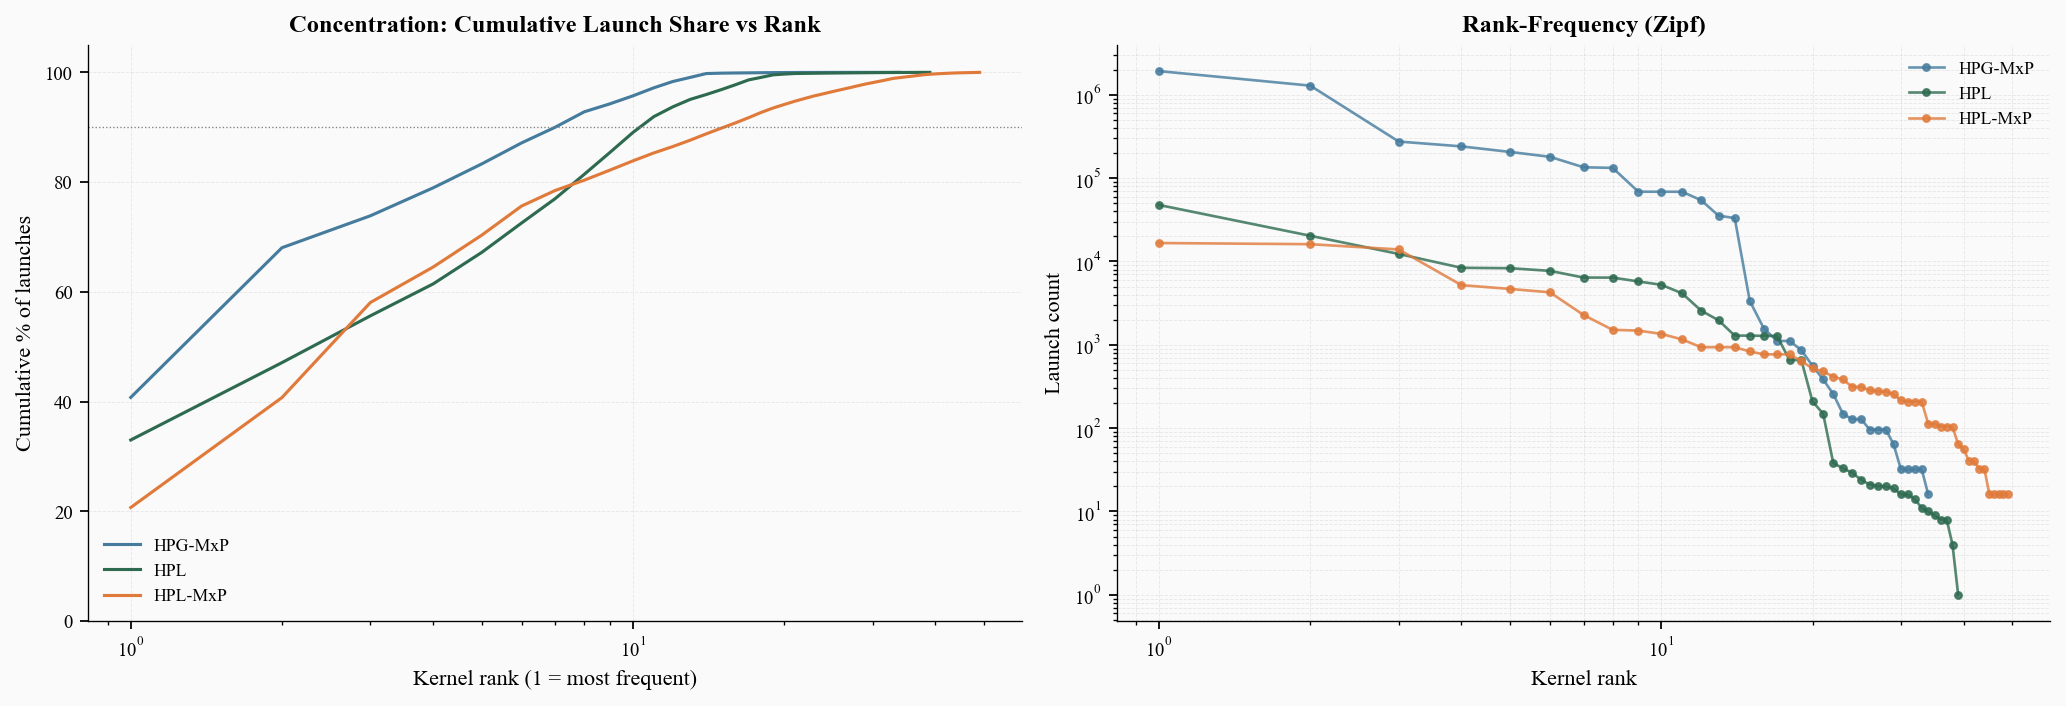

In [27]:
# -- Kernel diversity diagnostic --
if df_gpu.empty:
    print("No GPU kernel data.")
else:
    stats_rows = []
    for trace, sub in df_gpu.groupby('Trace'):
        counts = sub['Label'].value_counts()
        total  = counts.sum()
        probs  = counts.values / total
        entropy = float(-(probs * np.log2(probs)).sum())
        stats_rows.append({
            'Trace':            trace,
            'Total Kernels':    int(total),
            'Unique Labels':    int(len(counts)),
            'Unique Families':  int(sub['Family'].nunique()),
            'Top-1 Share %':    round(100*counts.iloc[0]/total, 1),
            'Top-5 Share %':    round(100*counts.head(5).sum()/total, 1),
            'Entropy (bits)':   round(entropy, 2),
        })
    stats = pd.DataFrame(stats_rows).sort_values('Entropy (bits)')
    print(stats.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG)
    for ax in axes: ax.set_facecolor(BG)

    for trace, sub in df_gpu.groupby('Trace'):
        counts = sub['Label'].value_counts().values
        ranks  = np.arange(1, len(counts) + 1)
        cum    = np.cumsum(counts) / counts.sum() * 100
        color  = TRACE_PALETTE.get(trace, '#888')
        axes[0].plot(ranks, cum, color=color, linewidth=1.4, label=trace)
        axes[1].loglog(ranks, counts, color=color, linewidth=1.2, marker='o',
                       markersize=3, label=trace, alpha=0.8)

    axes[0].set_xlabel('Kernel rank (1 = most frequent)')
    axes[0].set_ylabel('Cumulative % of launches')
    axes[0].set_title('Concentration: Cumulative Launch Share vs Rank',
                      fontweight='bold')
    axes[0].legend(frameon=False, fontsize=8)
    axes[0].grid(alpha=0.25, linestyle='--')
    axes[0].set_xscale('log')
    axes[0].set_ylim(0, 105)
    axes[0].axhline(90, color='grey', ls=':', lw=0.6)

    axes[1].set_xlabel('Kernel rank')
    axes[1].set_ylabel('Launch count')
    axes[1].set_title('Rank-Frequency (Zipf)', fontweight='bold')
    axes[1].legend(frameon=False, fontsize=8)
    axes[1].grid(alpha=0.25, linestyle='--', which='both')

    fig.tight_layout()
    fig.savefig('multi_kernel_diversity.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()


## 3 — Load per-device power traces

In [4]:
# -- Per-trace, per-device power --
# HPG-MxP and HPL-MxP don't necessarily record each device's energy counter on
# the rank the topology would predict. Scan every rank for every device and
# take the first rank that has a non-empty series.
power_traces = {}  # {(trace_label, device_id): (times, power)}
for label, path in TRACE_PATHS.items():
    abs_p = os.path.abspath(path)
    if not os.path.isdir(abs_p): continue
    seen_devs = set()
    for dev in [0, 2, 4, 6]:
        name = f"A2rocm_smi:::energy_count:device={dev}"
        for rank_id in range(8):
            mpath = os.path.join(abs_p, f"MPI Rank {rank_id}_metrics.csv")
            if not os.path.exists(mpath): continue
            m = pd.read_csv(mpath)
            sub = m[m['Metric Name'] == name].sort_values('Time')
            if len(sub) < 3: continue
            t = sub['Time'].values
            e = sub['Value'].values * 1e-6   # μJ → J
            dt = np.diff(t); de = np.diff(e)
            with np.errstate(divide='ignore', invalid='ignore'):
                p = np.where((dt > 0) & (de >= 0), de/dt, 0.0)
            power_traces[(label, dev)] = (t[1:], p)
            seen_devs.add(dev)
            break
    print(f"  {label}: devices loaded {sorted(seen_devs)}")
print(f"\nTotal (trace, device) power series: {len(power_traces)}")


  HPL: devices loaded [0, 2, 4, 6]
  HPL-MxP: devices loaded [0, 2, 4, 6]
  HPG-MxP: devices loaded [6]

Total (trace, device) power series: 9


## 4 — Correlate BLAS calls with GPU kernels and power

In [26]:
# -- Build a sorted index of GPU kernels per (trace, GCD) --
gpu_by_key = {k: sub.sort_values('Start Time').reset_index(drop=True)
              for k, sub in df_gpu.groupby(['Trace', 'GCD'])}

records = []
for _, row in df_cpu.iterrows():
    trace = row['Trace']
    gcd   = row['Rank_ID']
    dev   = GCD_TO_DEVICE[gcd]
    t0, t1 = row['Start Time'], row['End Time']

    g = gpu_by_key.get((trace, gcd))
    if g is None or len(g) == 0:
        kern_labels, kern_fams = [], []
    else:
        starts = g['Start Time'].values
        idx = np.where((starts >= t0) & (starts < t1))[0]
        kern_labels = g['Label'].iloc[idx].tolist()
        kern_fams   = g['Family'].iloc[idx].tolist()

    pt_pv = power_traces.get((trace, dev))
    if pt_pv is not None:
        pt, pv = pt_pv
        pm = (pt >= t0) & (pt <= t1)
        p_in = pv[pm]
    else:
        p_in = np.array([])

    records.append({
        'Trace':       trace,
        'Call':        row['Short'],
        'Rank':        gcd,
        'Device':      dev,
        'Start':       t0,
        'End':         t1,
        'Duration':    row['Duration'],
        'NumKernels':  len(kern_labels),
        'KernelLabels':kern_labels,
        'KernelFams':  kern_fams,
        'FirstLabel':  kern_labels[0] if kern_labels else None,
        'PowerMax':    float(p_in.max())  if len(p_in) else np.nan,
        'PowerMean':   float(p_in.mean()) if len(p_in) else np.nan,
        'PowerSamples':len(p_in),
    })

corr = pd.DataFrame(records)
print(f"Total correlated calls: {len(corr):,}")
print(f"\nCalls with ≥1 kernel, by trace:")
print(corr[corr['NumKernels']>0].groupby('Trace').size().to_string())
print(f"\nCalls with power samples, by trace:")
print(corr[corr['PowerSamples']>0].groupby('Trace').size().to_string())

Total correlated calls: 315,508

Calls with ≥1 kernel, by trace:
Trace
HPG-MxP    33378
HPL        29911
HPL-MxP     3515

Calls with power samples, by trace:
Trace
HPG-MxP    1791
HPL        7314
HPL-MxP    1191


## Figure 1 — Kernel family mix per BLAS function (pooled across traces)

Stacked horizontal bars. Each row is one BLAS function; the bar is split by GPU kernel family,
summed across every trace.

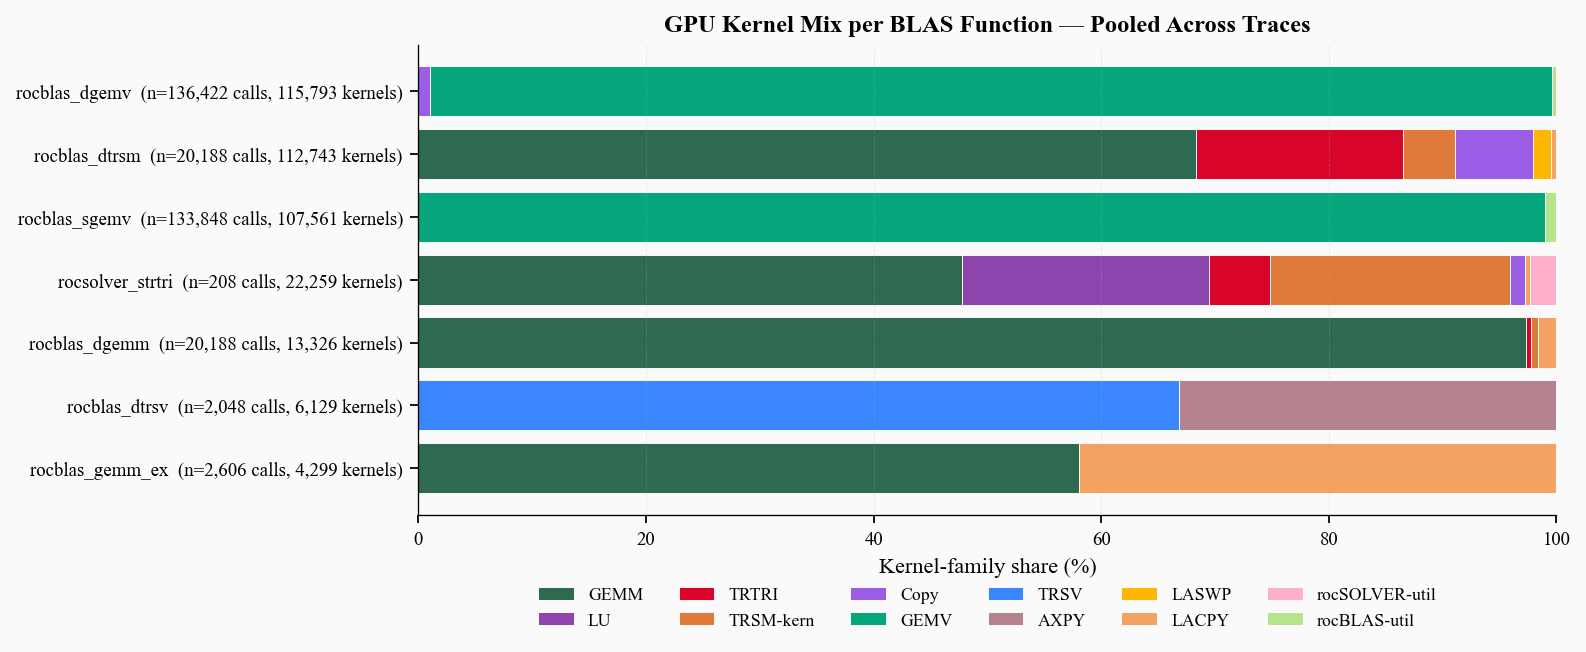

In [6]:
# -- Fig 1: pooled kernel mix per BLAS function --
rows = []
for call, sub in corr.groupby('Call'):
    fams = [f for fs in sub['KernelFams'] for f in fs]
    if not fams: continue
    c = Counter(fams); total = sum(c.values())
    rows.append({'Call': call, 'TotalKernels': total, 'NumCalls': len(sub),
                 **{fam: 100*c.get(fam,0)/total for fam in FAMILY_PALETTE}})

if not rows:
    print("No kernel data correlated with BLAS calls.")
else:
    mix = pd.DataFrame(rows).sort_values('TotalKernels', ascending=False).reset_index(drop=True)
    fams_present = [f for f in FAMILY_PALETTE if (mix[f] > 0.1).any()]

    fig, ax = plt.subplots(figsize=(10, max(3, 0.6*len(mix))), facecolor=BG)
    ax.set_facecolor(BG)
    left = np.zeros(len(mix))
    for fam in fams_present:
        vals = mix[fam].values
        ax.barh(range(len(mix)), vals, left=left,
                color=FAMILY_PALETTE[fam], label=fam,
                edgecolor='white', linewidth=0.4)
        left += vals
    ax.set_yticks(range(len(mix)))
    ax.set_yticklabels([f"{r.Call}  (n={r.NumCalls:,} calls, {r.TotalKernels:,} kernels)"
                        for r in mix.itertuples()], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel('Kernel-family share (%)'); ax.set_xlim(0, 100)
    ax.set_title('GPU Kernel Mix per BLAS Function — Pooled Across Traces',
                  fontweight='bold')
    ax.legend(ncol=min(6, len(fams_present)), frameon=False, fontsize=8,
              loc='upper center', bbox_to_anchor=(0.5, -0.12))
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    fig.tight_layout()
    fig.savefig('multi_fig1_mix.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 2 — GEMM tile-variant usage, facetted by trace

How does each trace distribute its `Cijk_*_MT*` launches? Same variants dominating across
traces implies a canonical BLAS heuristic; divergent choices hint at problem-size or
parameter-driven code paths.

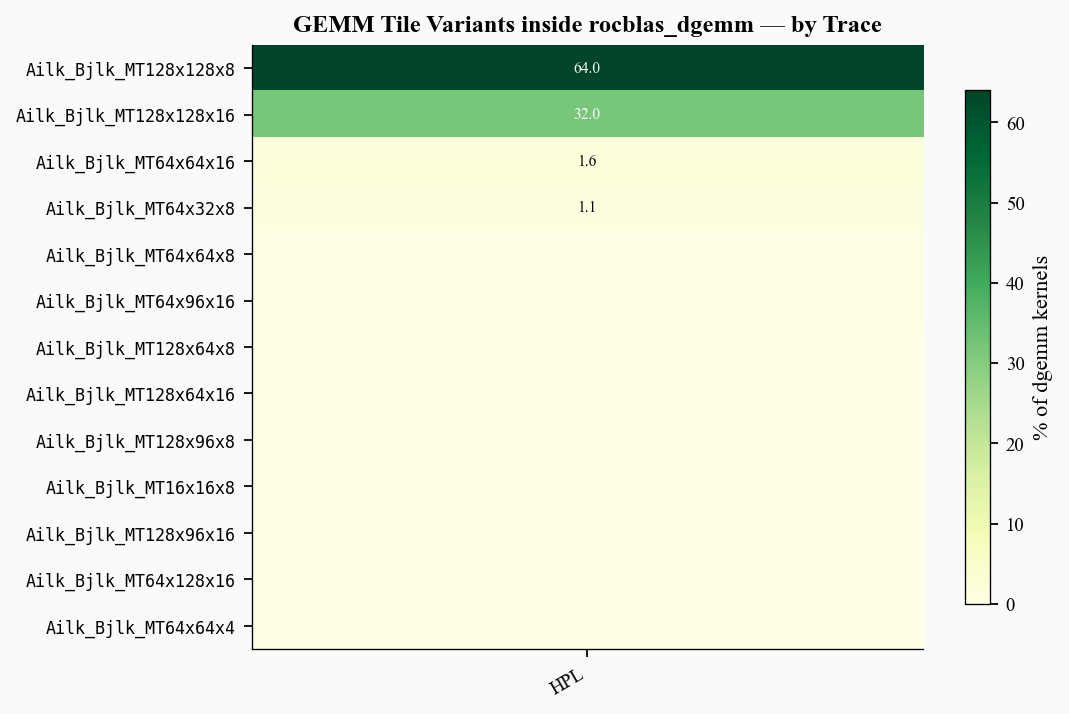

In [7]:
# -- Fig 2: GEMM variant breakdown per trace --
dgemm = corr[corr['Call']=='rocblas_dgemm']

trace_variants = {}
for trace, sub in dgemm.groupby('Trace'):
    all_lbls = [l for ls in sub['KernelLabels'] for l in ls]
    gemm_lbls = [l for l in all_lbls if l.startswith('Cijk_')]
    if gemm_lbls:
        trace_variants[trace] = Counter(gemm_lbls)

if not trace_variants:
    print("No GEMM kernels captured.")
else:
    # Union of top-15 per trace, then pick the global top 15 by pooled count
    pooled = Counter()
    for c in trace_variants.values(): pooled.update(c)
    top_labels = [t for t,_ in pooled.most_common(15)]

    # Build matrix: rows = labels, columns = traces, values = %
    mat = np.zeros((len(top_labels), len(trace_variants)))
    trace_list = list(trace_variants.keys())
    for j, tr in enumerate(trace_list):
        c = trace_variants[tr]; total = sum(c.values())
        for i, lbl in enumerate(top_labels):
            mat[i, j] = 100 * c.get(lbl, 0) / total if total else 0

    fig, ax = plt.subplots(figsize=(max(7, 0.9*len(trace_list)+6),
                                     max(4, 0.35*len(top_labels))), facecolor=BG)
    ax.set_facecolor(BG)
    im = ax.imshow(mat, aspect='auto', cmap='YlGn', vmin=0)
    ax.set_xticks(range(len(trace_list)))
    ax.set_xticklabels(trace_list, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticks(range(len(top_labels)))
    ax.set_yticklabels([l.replace('Cijk_','') for l in top_labels],
                        fontsize=7.5, family='monospace')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i,j]
            if v > 0.3:
                ax.text(j, i, f"{v:.1f}", ha='center', va='center',
                        fontsize=7, color='white' if v>15 else 'black')
    cb = plt.colorbar(im, ax=ax, shrink=0.85); cb.set_label('% of dgemm kernels')
    ax.set_title('GEMM Tile Variants inside rocblas_dgemm — by Trace',
                  fontweight='bold')
    fig.tight_layout()
    fig.savefig('multi_fig2_gemm_by_trace.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 3 — rocblas_dtrsm decomposition per trace

Same idea but for TRSM: the label mix tells us how a trace's problem sizes steer the
block-triangular solve into different helper kernels.

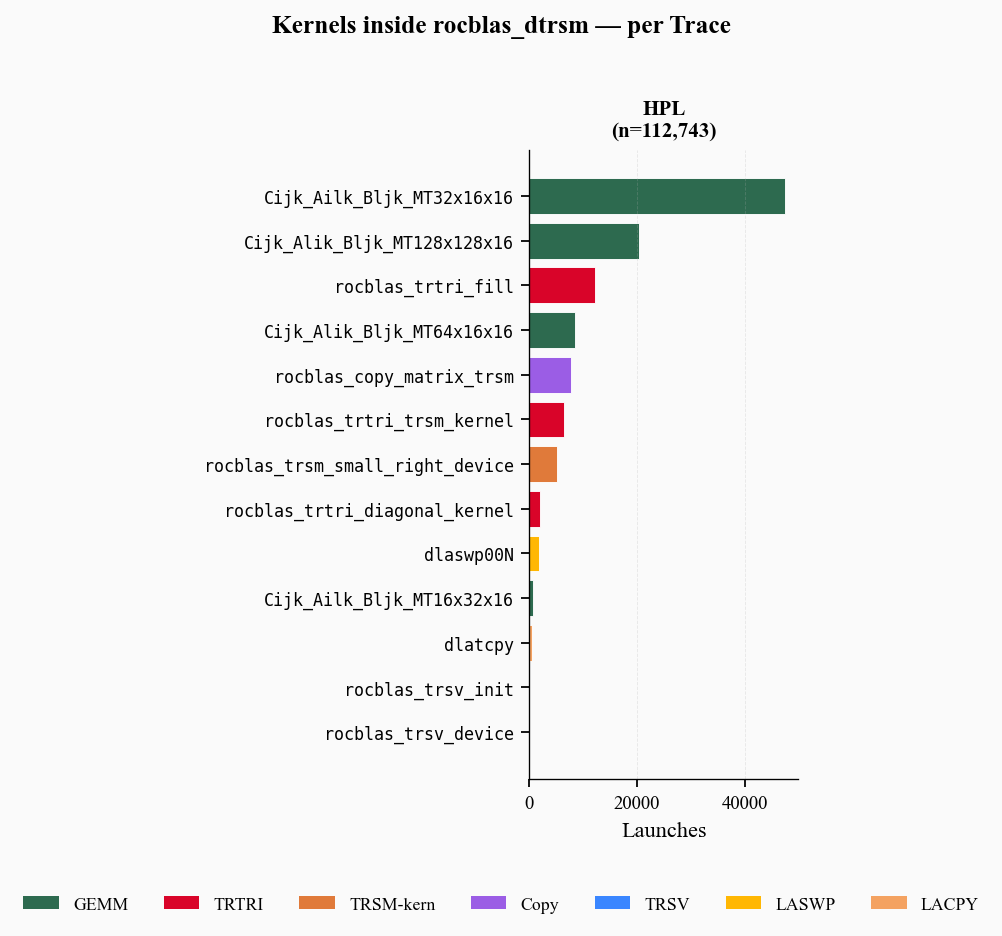

In [8]:
# -- Fig 3: dtrsm label breakdown per trace --
dtrsm = corr[corr['Call']=='rocblas_dtrsm']

trace_trsm = {}
for trace, sub in dtrsm.groupby('Trace'):
    lbls = [l for ls in sub['KernelLabels'] for l in ls]
    if lbls: trace_trsm[trace] = Counter(lbls)

if not trace_trsm:
    print("No dtrsm kernels captured.")
else:
    pooled = Counter()
    for c in trace_trsm.values(): pooled.update(c)
    top_labels = [t for t,_ in pooled.most_common(15)]
    trace_list = list(trace_trsm.keys())

    fig, axes = plt.subplots(1, len(trace_list), figsize=(4*len(trace_list), max(4, 0.4*len(top_labels))),
                             sharey=True, facecolor=BG)
    if len(trace_list) == 1: axes = [axes]

    for ax, tr in zip(axes, trace_list):
        ax.set_facecolor(BG)
        c = trace_trsm[tr]; total = sum(c.values())
        counts = [c.get(lbl, 0) for lbl in top_labels]
        colors = [FAMILY_PALETTE.get(gpu_family(lbl), '#999') for lbl in top_labels]
        ax.barh(range(len(top_labels)), counts, color=colors,
                edgecolor='white', linewidth=0.4)
        ax.invert_yaxis()
        ax.set_xlabel('Launches')
        ax.set_title(f'{tr}\n(n={total:,})', fontsize=9.5, fontweight='bold')
        ax.grid(axis='x', alpha=0.25, linestyle='--')

    axes[0].set_yticks(range(len(top_labels)))
    axes[0].set_yticklabels(top_labels, fontsize=7.5, family='monospace')
    fig.suptitle('Kernels inside rocblas_dtrsm — per Trace', fontweight='bold', y=1.02)

    handles = [mpatches.Patch(facecolor=FAMILY_PALETTE[f], label=f)
               for f in FAMILY_PALETTE if f in [gpu_family(l) for l in top_labels]]
    fig.legend(handles=handles, frameon=False, fontsize=8,
                loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=len(handles))
    fig.tight_layout()
    fig.savefig('multi_fig3_dtrsm_by_trace.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 4 — Per-call peak power distributions, grouped by trace

Violin (per BLAS function) with one shaded violin per trace side-by-side to reveal whether
the same call draws different power in different runs.

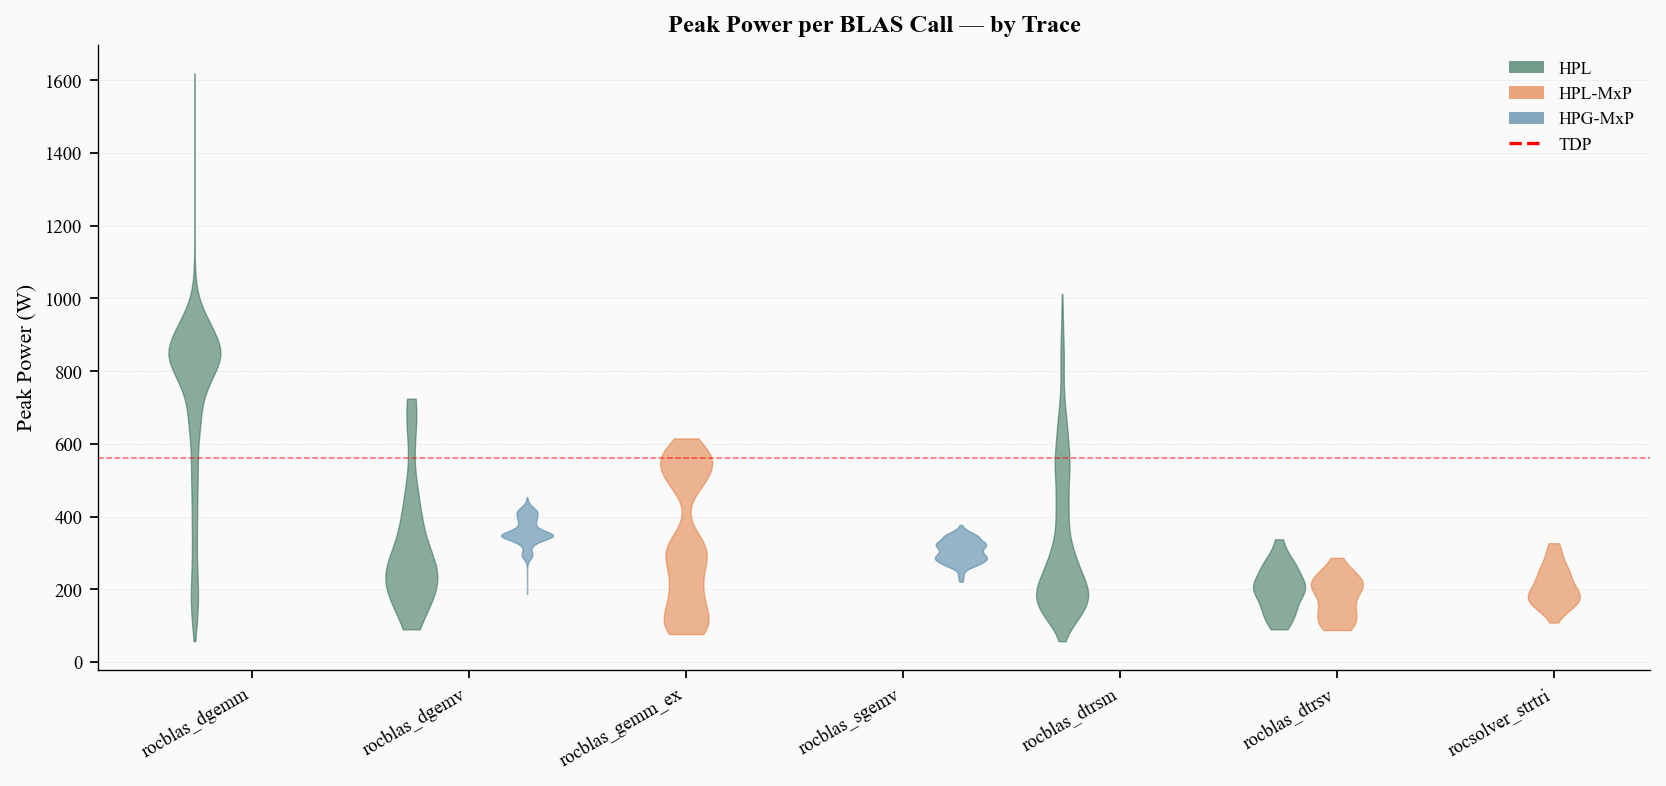

In [9]:
# -- Fig 4: peak-power violins per (call, trace) --
pd_df = corr[corr['PowerSamples'] > 0].copy()
if pd_df.empty:
    print("No power data.")
else:
    call_order = (pd_df.groupby('Call')['PowerMax'].median()
                  .sort_values(ascending=False).index.tolist())
    traces = list(TRACE_PATHS.keys())

    fig, ax = plt.subplots(figsize=(max(7, 1.5*len(call_order)), 5), facecolor=BG)
    ax.set_facecolor(BG)

    width = 0.8 / max(1, len(traces))
    for i, tr in enumerate(traces):
        offset = (i - (len(traces)-1)/2) * width
        vals = [pd_df[(pd_df['Call']==c)&(pd_df['Trace']==tr)]['PowerMax'].dropna().values
                for c in call_order]
        positions = [j + offset for j, v in enumerate(vals) if len(v) >= 3]
        data     = [v for v in vals if len(v) >= 3]
        if not data: continue
        vp = ax.violinplot(data, positions=positions, widths=width*0.9,
                           showextrema=False)
        for body in vp['bodies']:
            body.set_facecolor(TRACE_PALETTE.get(tr, '#888'))
            body.set_alpha(0.55)
            body.set_edgecolor(TRACE_PALETTE.get(tr, '#888'))
            body.set_linewidth(0.6)
    ax.axhline(TDP_THRESHOLD, color='red', linestyle='--', linewidth=0.7, alpha=0.6, label='TDP')
    ax.set_xticks(range(len(call_order)))
    ax.set_xticklabels(call_order, rotation=30, ha='right')
    ax.set_ylabel('Peak Power (W)')
    ax.set_title('Peak Power per BLAS Call — by Trace', fontweight='bold')
    handles = [mpatches.Patch(facecolor=TRACE_PALETTE.get(tr,'#888'), label=tr, alpha=0.65)
               for tr in traces]
    ax.legend(handles=handles + [Line2D([0],[0], color='red', ls='--', label='TDP')],
              frameon=False, fontsize=8)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    fig.tight_layout()
    fig.savefig('multi_fig4_power_by_call_trace.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 5 — Top GPU kernels by peak power, pooled across traces

First-launched kernel in each BLAS window vs. the peak power observed over that window.

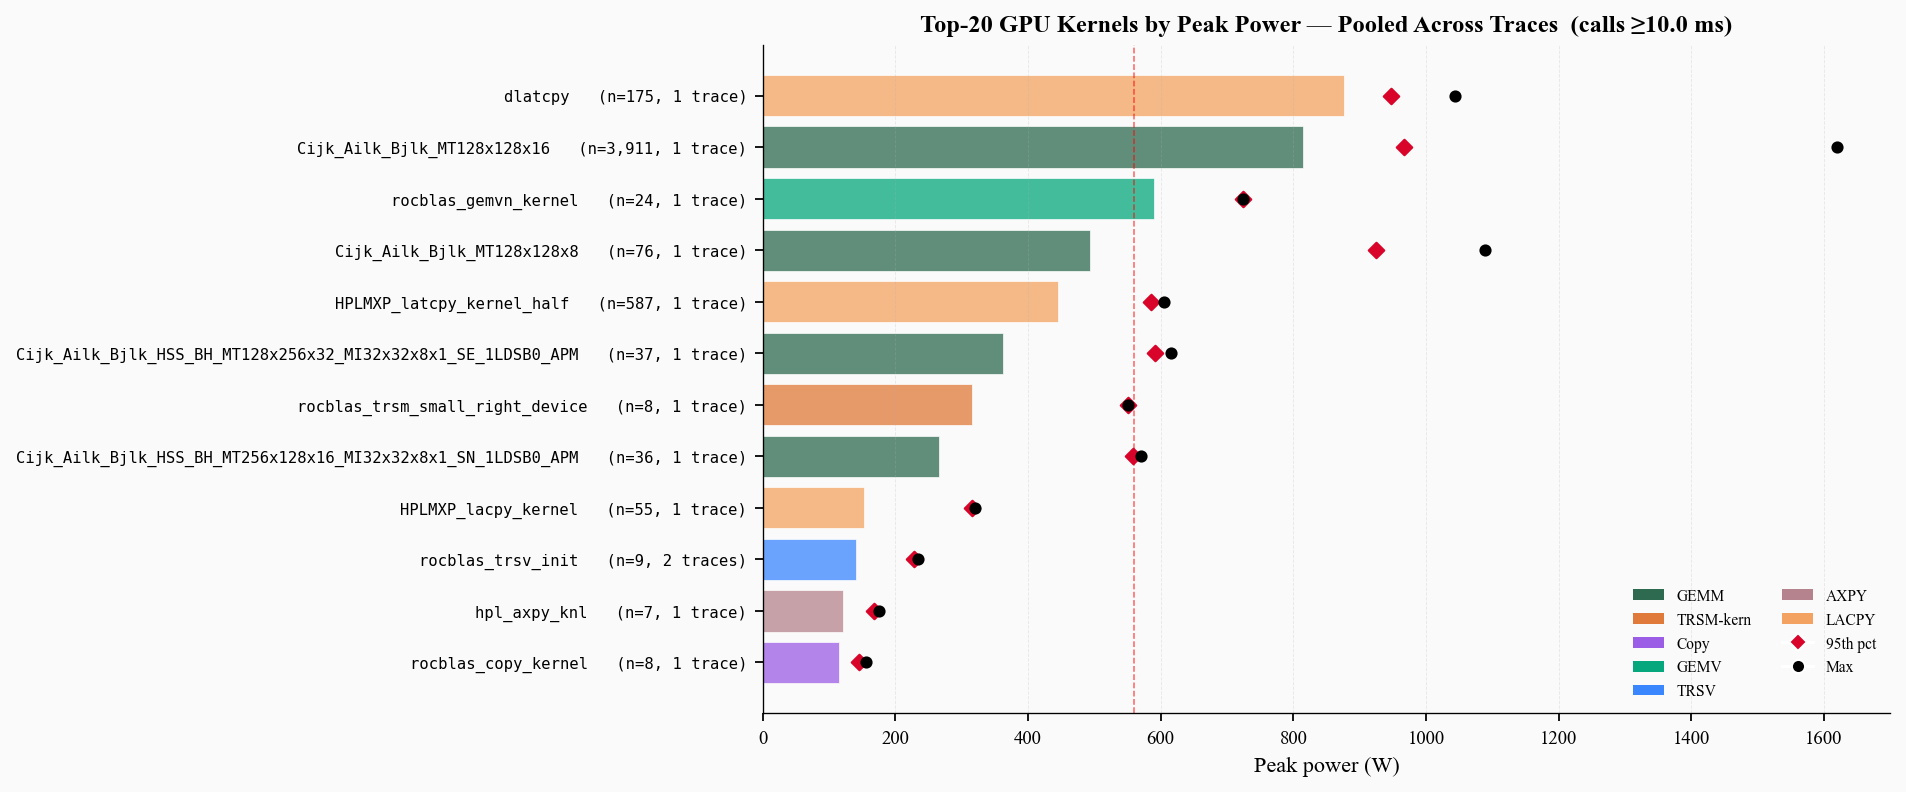

In [25]:
# -- Fig 5: pooled peak power per first-launched kernel --
KERNEL_MS_THRESHOLD=1e-2
with_kern = corr[(corr['FirstLabel'].notna()) & (corr['PowerSamples']>0) & (corr['Duration'] >= KERNEL_MS_THRESHOLD)].copy()
if with_kern.empty:
    print("No kernel→power data.")
else:
    stats = (with_kern.groupby('FirstLabel')
             .agg(count=('PowerMax','size'),
                  mean_peak=('PowerMax','mean'),
                  p95_peak=('PowerMax', lambda s: np.percentile(s, 95)),
                  max_peak=('PowerMax','max'),
                  family=('FirstLabel', lambda s: gpu_family(s.iloc[0])),
                  traces=('Trace', lambda s: s.nunique()))
             .reset_index())
    stats = stats[stats['count'] >= 5].sort_values('mean_peak', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12, max(4, 0.42*len(stats))), facecolor=BG)
    ax.set_facecolor(BG)
    colors = [FAMILY_PALETTE.get(f, '#999') for f in stats['family']]
    y = np.arange(len(stats))
    ax.barh(y, stats['mean_peak'], color=colors, alpha=0.75,
            edgecolor='white', linewidth=0.4, label='Mean peak')
    ax.scatter(stats['p95_peak'], y, color='#d90429', s=24, marker='D',
               zorder=5, label='95th pct')
    ax.scatter(stats['max_peak'], y, color='black', s=20, marker='o',
               zorder=5, label='Max')
    ax.axvline(TDP_THRESHOLD, color='red', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{lbl}   (n={cnt:,}, {tr} trace{'s' if tr!=1 else ''})"
                        for lbl, cnt, tr in zip(stats['FirstLabel'], stats['count'], stats['traces'])],
                        fontsize=7, family='monospace')
    ax.invert_yaxis()
    ax.set_xlabel('Peak power (W)')
    ax.set_title(f'Top-20 GPU Kernels by Peak Power — Pooled Across Traces  (calls ≥{KERNEL_MS_THRESHOLD*1000} ms)', fontweight='bold')
    fam_handles = [mpatches.Patch(facecolor=FAMILY_PALETTE[f], label=f)
                   for f in FAMILY_PALETTE if f in stats['family'].values]
    ax.legend(handles=fam_handles + [
        Line2D([0],[0], marker='D', color='w', markerfacecolor='#d90429', label='95th pct', markersize=6),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='black', label='Max', markersize=6),
    ], frameon=False, fontsize=7, loc='lower right', ncol=2)
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    fig.tight_layout()
    fig.savefig('multi_fig5_kernel_power_pooled.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 6 — BLAS-call 3-gram sequences by peak power

Pool all traces, slide a 3-call window, rank sequences by mean peak power.

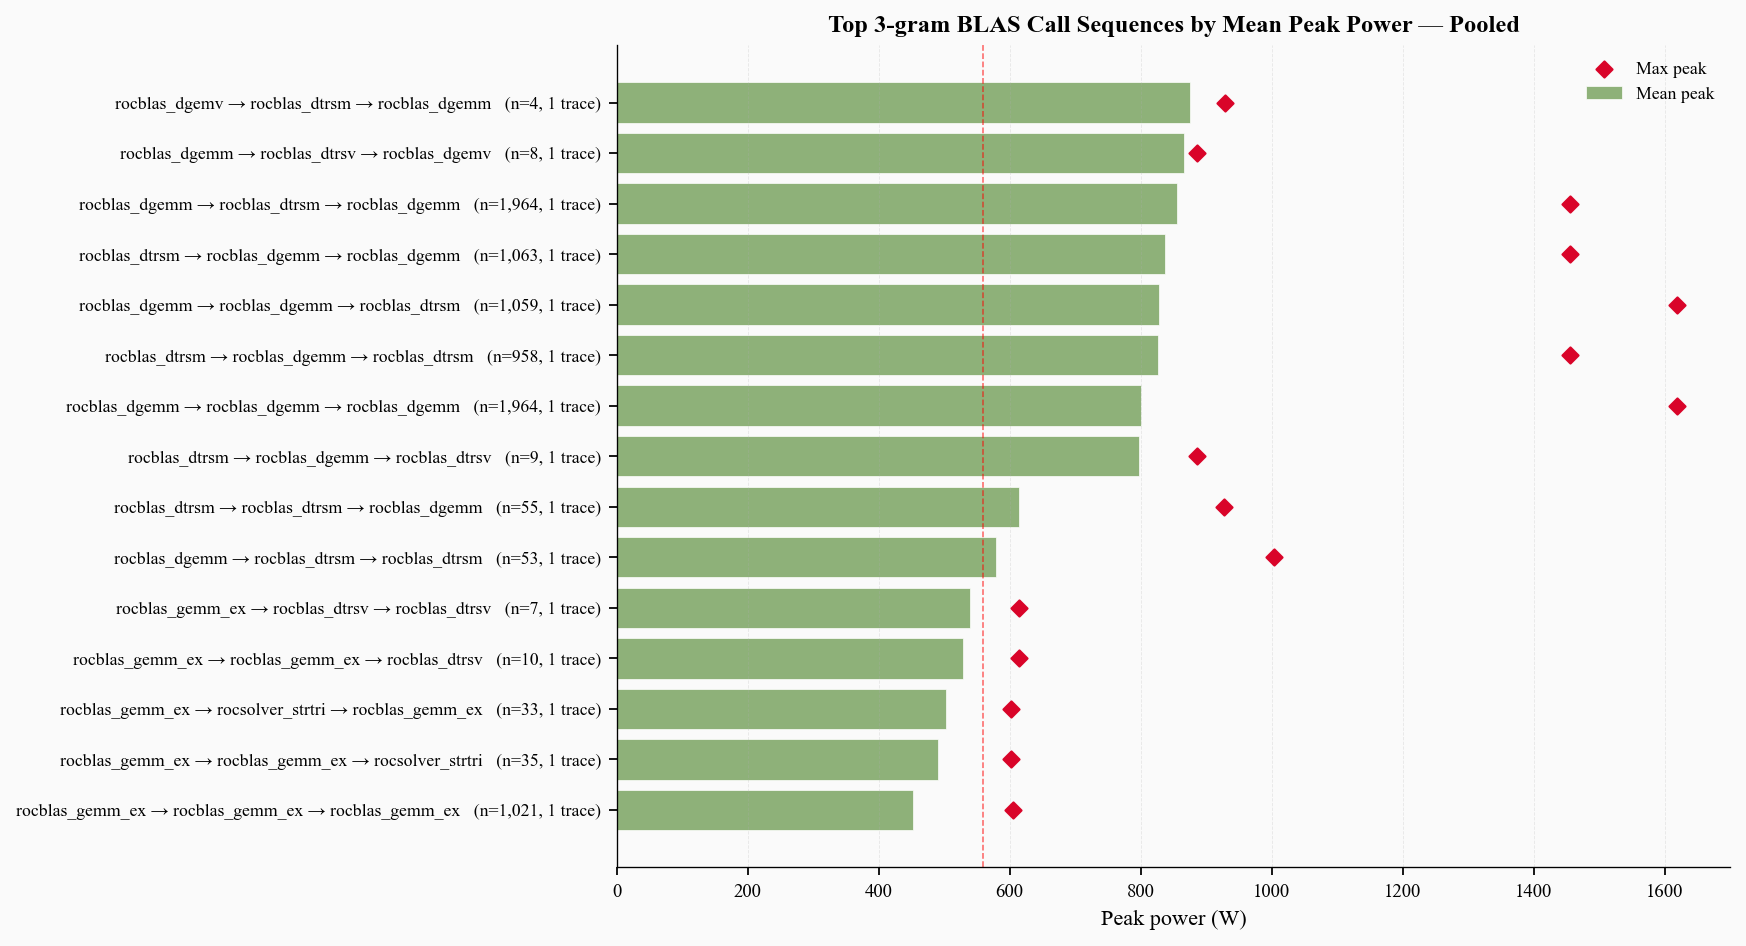

In [11]:
# -- Fig 6: pooled BLAS-call 3-grams vs peak power --
N = 3
co = corr[corr['PowerSamples']>0].sort_values(['Trace','Rank','Start']).reset_index(drop=True)

ngrams = []
for (trace, rid), sub in co.groupby(['Trace','Rank']):
    calls = sub['Call'].tolist()
    peaks = sub['PowerMax'].tolist()
    for i in range(len(calls)-N+1):
        ngrams.append({'ngram': ' → '.join(calls[i:i+N]),
                       'peak': max(peaks[i:i+N]),
                       'trace': trace})

if not ngrams:
    print("No n-gram data.")
else:
    nd = pd.DataFrame(ngrams)
    st = (nd.groupby('ngram')
          .agg(count=('peak','size'),
               mean_peak=('peak','mean'),
               max_peak=('peak','max'),
               traces=('trace', lambda s: s.nunique()))
          .reset_index())
    st = st[st['count'] >= max(2, int(st['count'].median()))]
    st = st.sort_values('mean_peak', ascending=False).head(15)

    if st.empty:
        print("Not enough data after frequency filter.")
    else:
        fig, ax = plt.subplots(figsize=(11, max(4, 0.4*len(st))), facecolor=BG)
        ax.set_facecolor(BG)
        y = np.arange(len(st))
        ax.barh(y, st['mean_peak'], color='#6a994e', alpha=0.75,
                edgecolor='white', linewidth=0.4, label='Mean peak')
        ax.scatter(st['max_peak'], y, color='#d90429', s=26, marker='D',
                   zorder=5, label='Max peak')
        ax.axvline(TDP_THRESHOLD, color='red', linestyle='--', linewidth=0.7, alpha=0.6)
        ax.set_yticks(y)
        ax.set_yticklabels([f"{g}   (n={c:,}, {tr} trace{'s' if tr!=1 else ''})"
                            for g, c, tr in zip(st['ngram'], st['count'], st['traces'])],
                            fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Peak power (W)')
        ax.set_title(f'Top {N}-gram BLAS Call Sequences by Mean Peak Power — Pooled',
                      fontweight='bold')
        ax.legend(frameon=False, fontsize=8)
        ax.grid(axis='x', alpha=0.25, linestyle='--')
        fig.tight_layout()
        fig.savefig('multi_fig6_ngrams_pooled.pdf', facecolor=BG, bbox_inches='tight')
        plt.show()

## Figure 7 — Kernel-family share per trace

How does each trace's *overall* GPU instruction mix compare? (Independent of which BLAS call
launched what.)

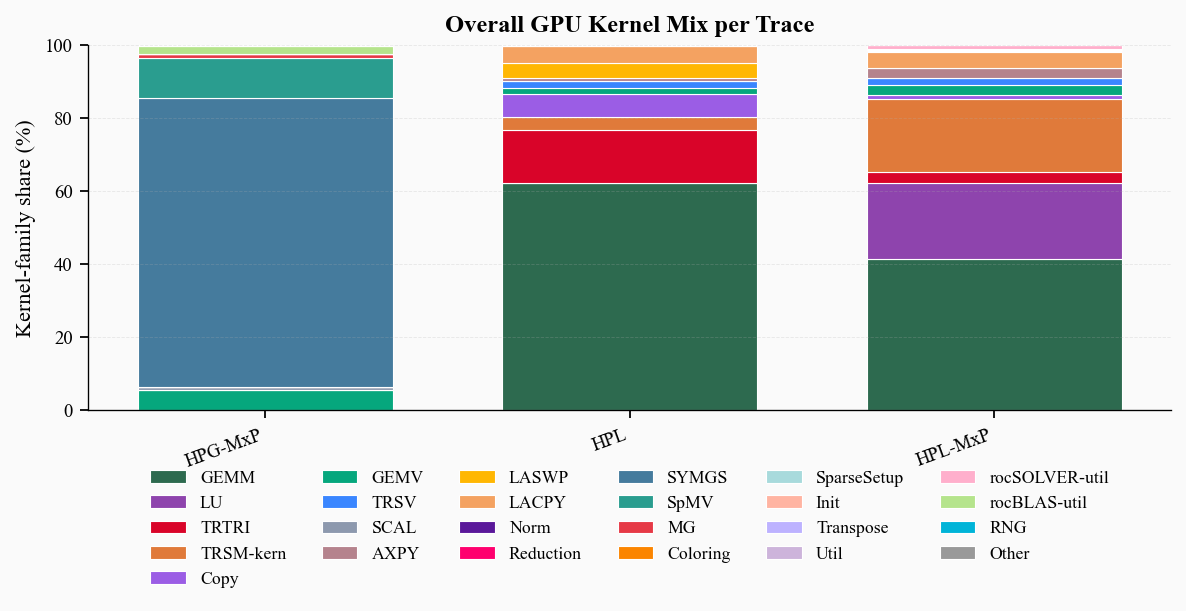

In [12]:
# -- Fig 7: per-trace kernel family share --
if df_gpu.empty:
    print("No GPU kernels loaded.")
else:
    pivot = (df_gpu.groupby(['Trace','Family']).size()
             .unstack(fill_value=0))
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    fams = [f for f in FAMILY_PALETTE if f in pivot_pct.columns]
    pivot_pct = pivot_pct[fams]

    fig, ax = plt.subplots(figsize=(max(7, 1.2*len(pivot_pct)+4), 4), facecolor=BG)
    ax.set_facecolor(BG)
    bottom = np.zeros(len(pivot_pct))
    xs = np.arange(len(pivot_pct))
    for fam in fams:
        vals = pivot_pct[fam].values
        ax.bar(xs, vals, bottom=bottom,
               color=FAMILY_PALETTE[fam], label=fam,
               edgecolor='white', linewidth=0.5, width=0.7)
        bottom += vals
    ax.set_xticks(xs); ax.set_xticklabels(pivot_pct.index, rotation=20, ha='right')
    ax.set_ylabel('Kernel-family share (%)'); ax.set_ylim(0, 100)
    ax.set_title('Overall GPU Kernel Mix per Trace', fontweight='bold')
    ax.legend(ncol=min(6, len(fams)), frameon=False, fontsize=8,
              loc='upper center', bbox_to_anchor=(0.5, -0.12))
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    fig.tight_layout()
    fig.savefig('multi_fig7_family_per_trace.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 8 — GPU kernel n-gram sequences by peak power

For each trace, slide a window of `NGRAM_SIZE` kernels over the launch stream on every GCD,
look up the maximum instantaneous power observed across the window, and rank the resulting
sequences. This surfaces the specific kernel-to-kernel transitions coinciding with power
spikes — useful for identifying which kernel patterns are thermally or energy-problematic.

Both **label-level** (specific kernel variants) and **family-level** (coarser categories)
n-grams are shown. Set `NGRAM_SIZE = 2` for pairs or `3` for triplets.


Total n-grams with power data: 30,990


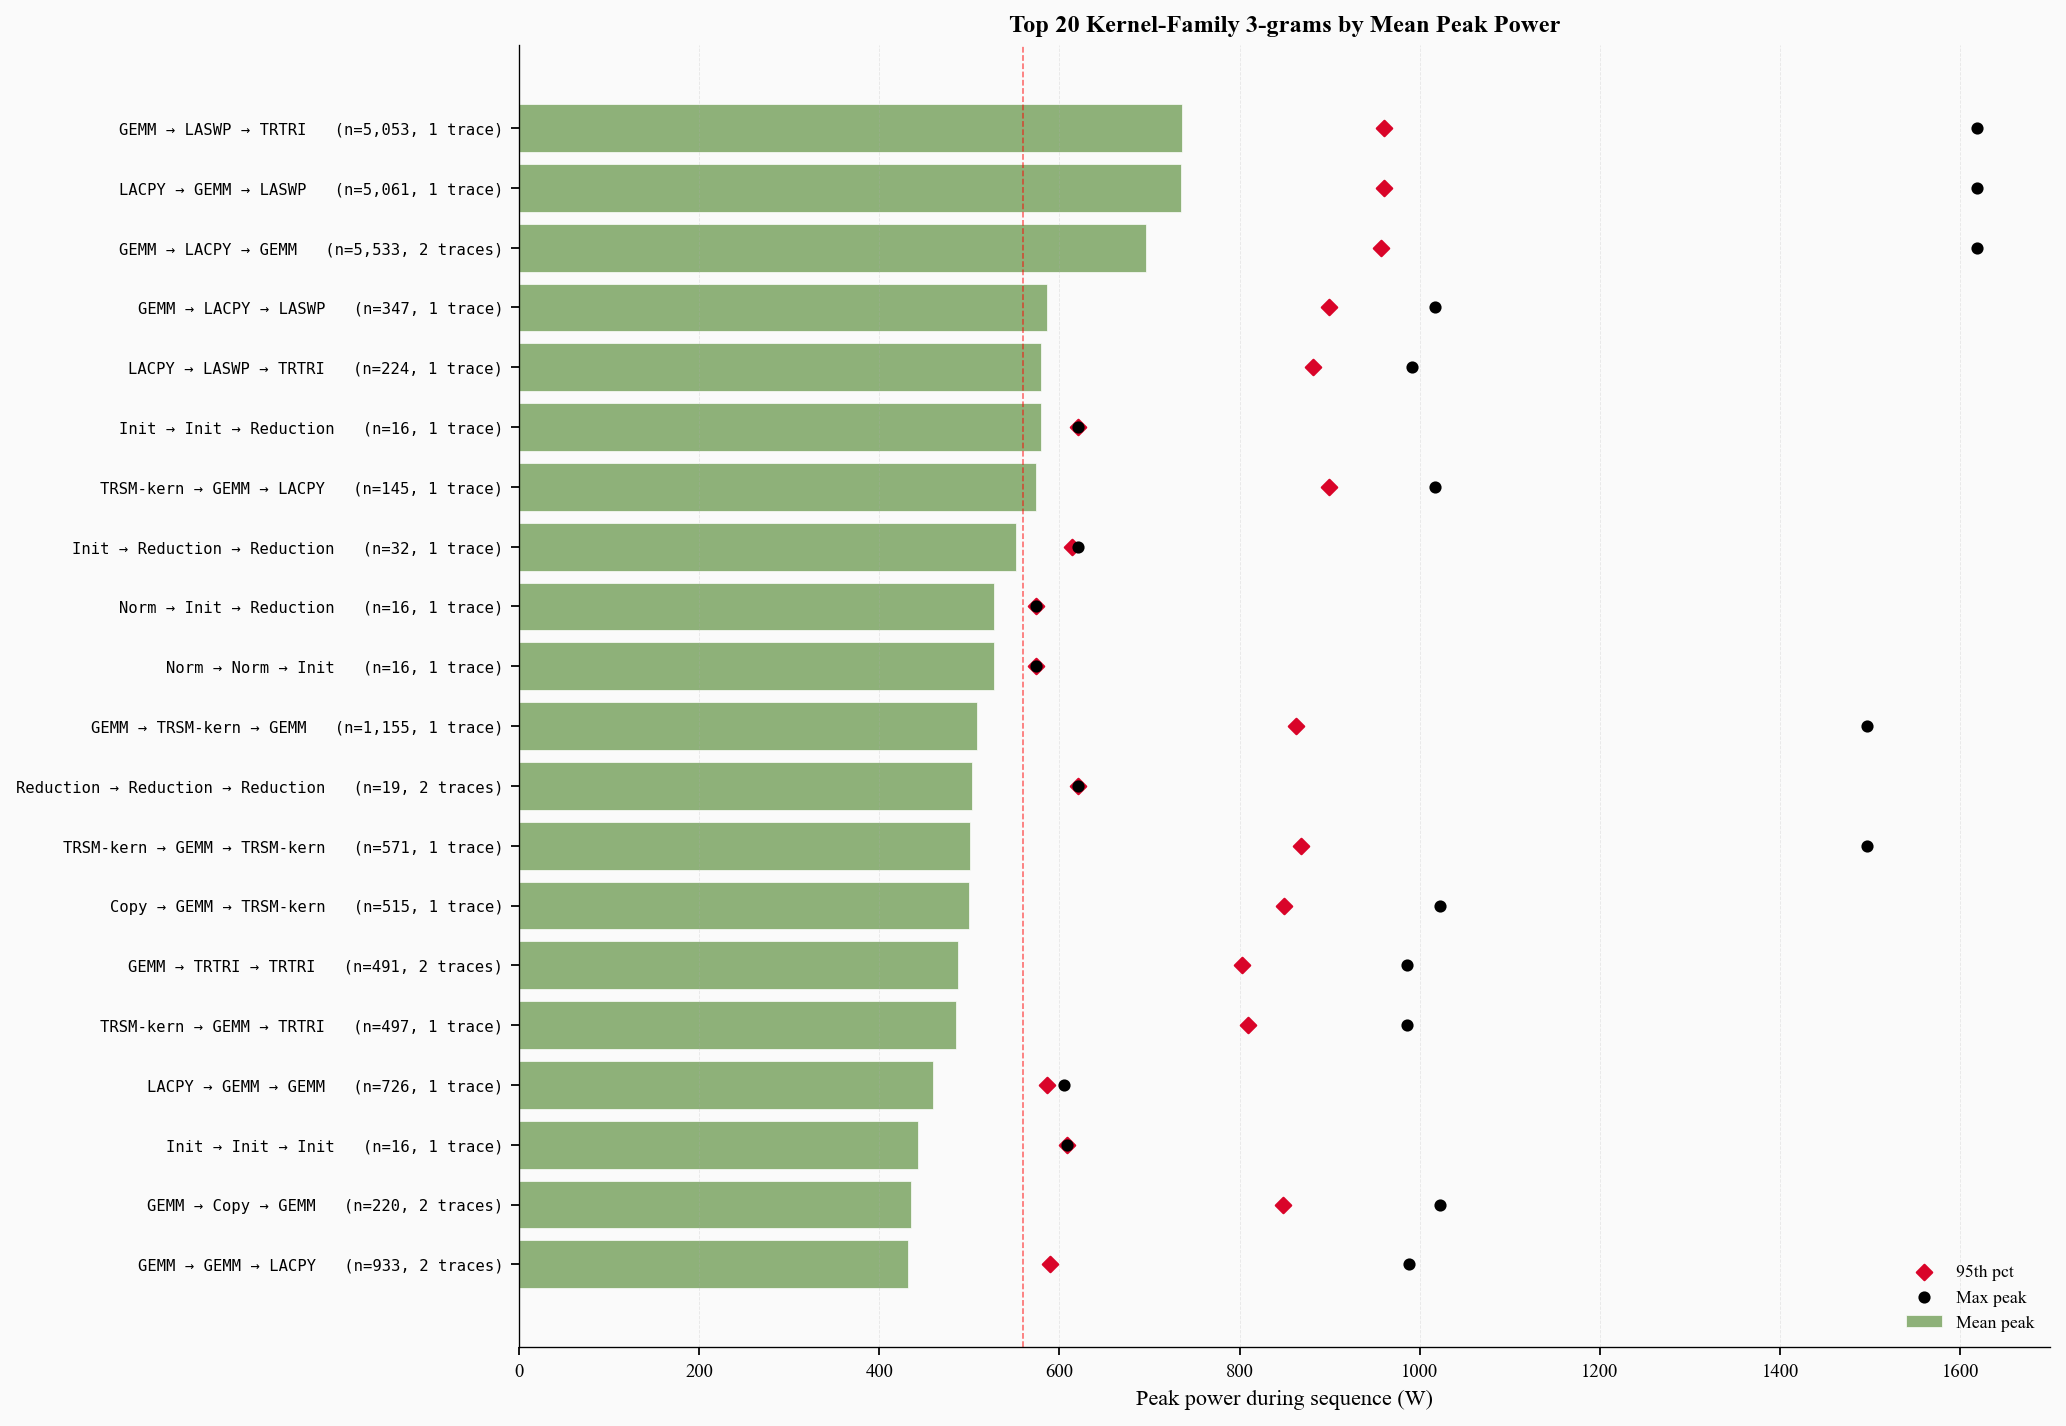

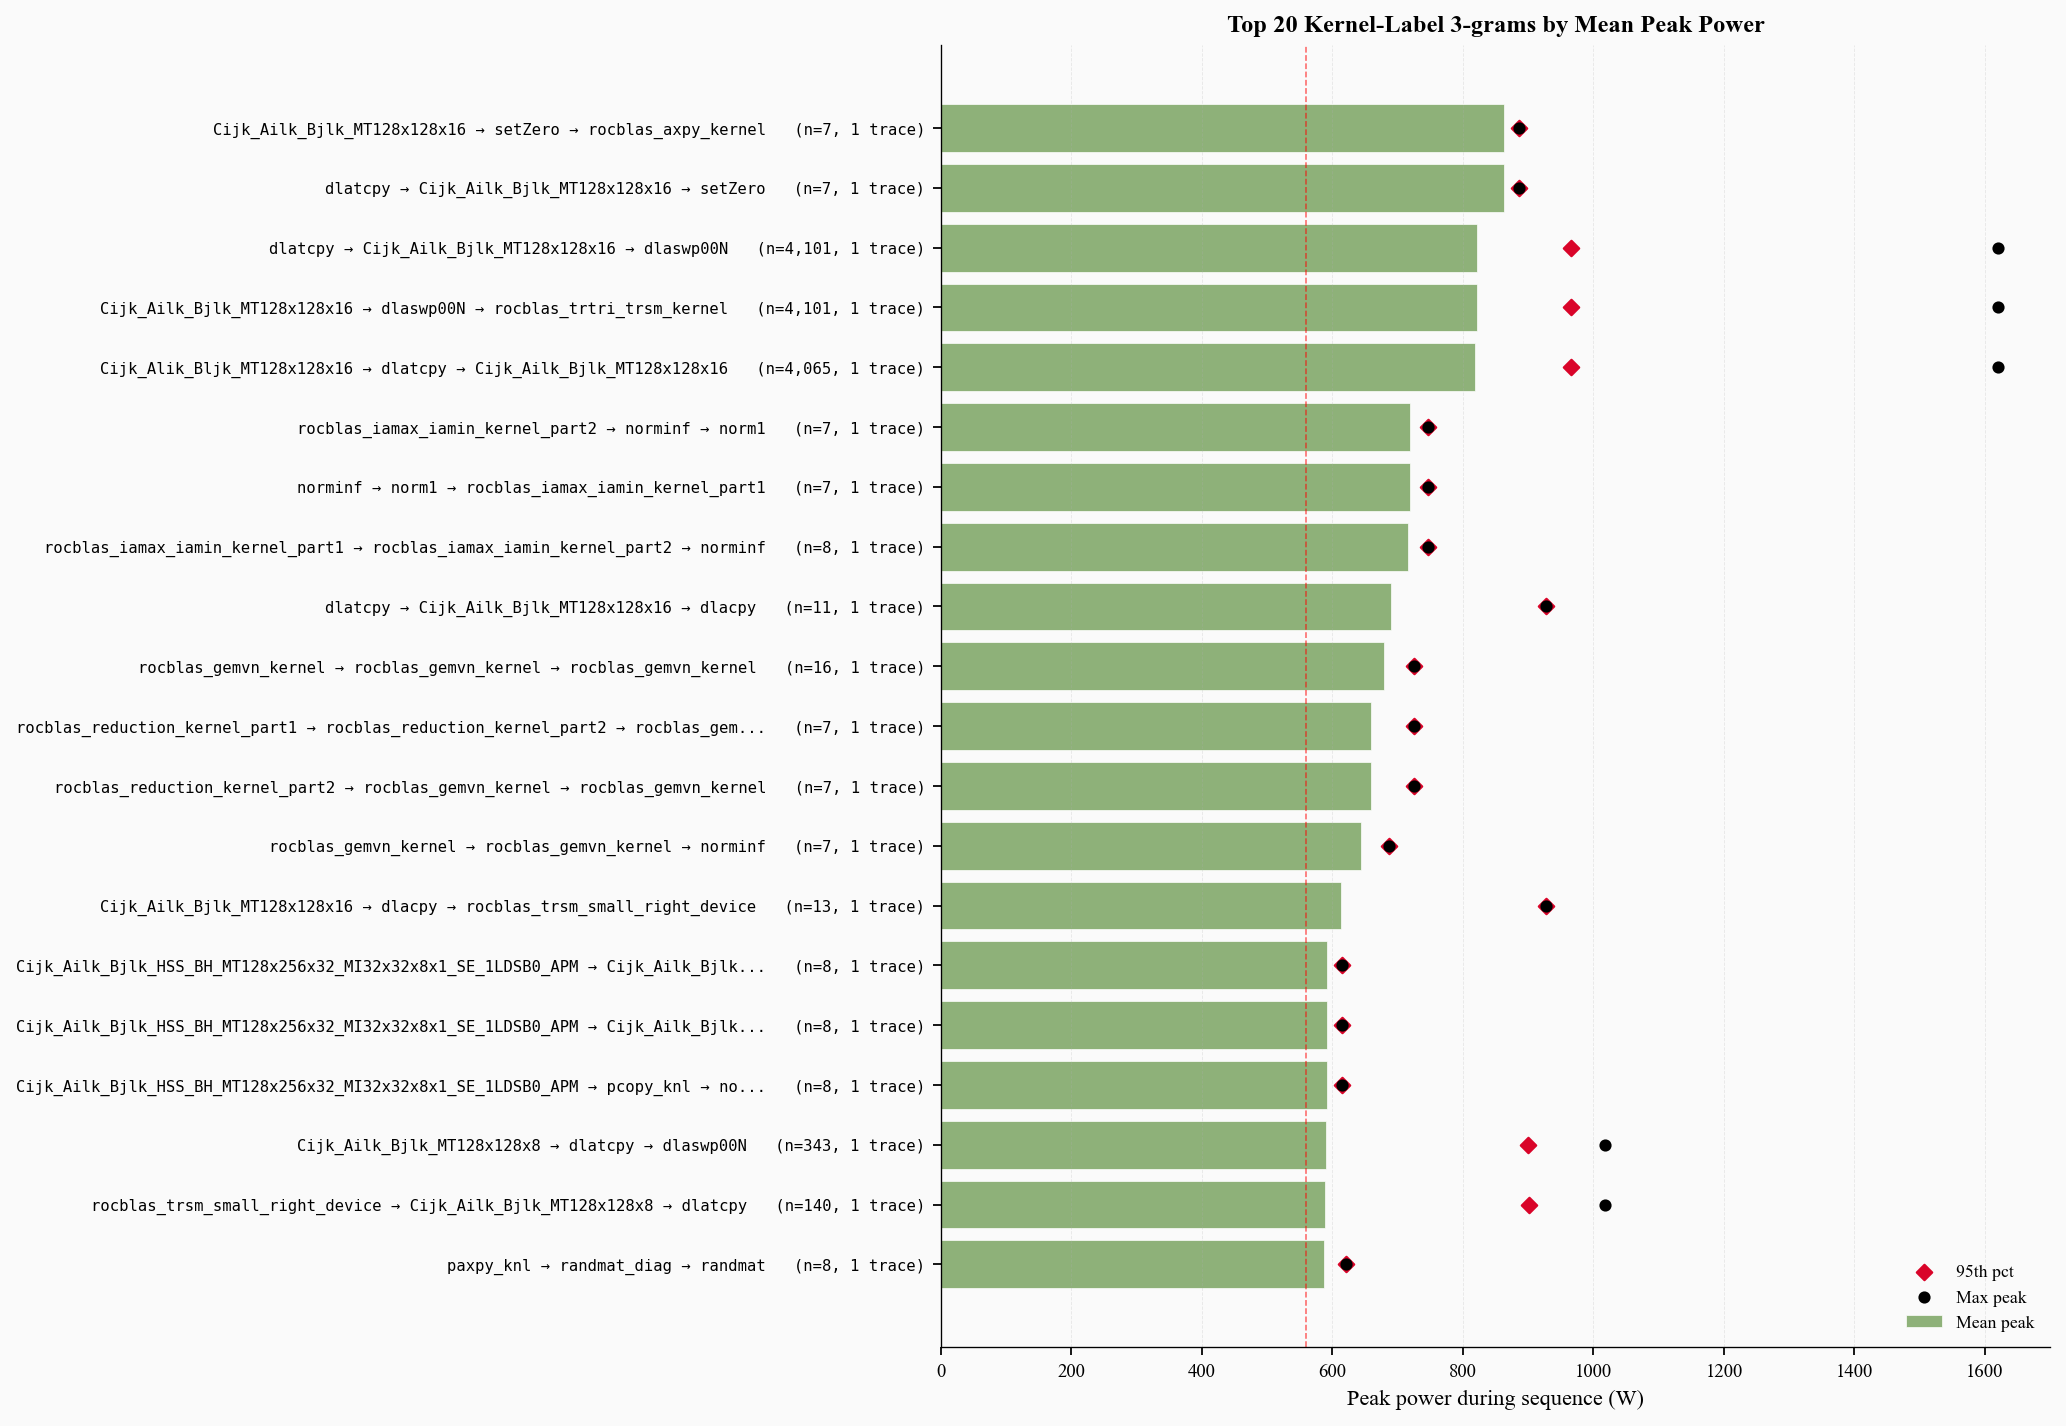

In [ ]:
# -- Fig 8: GPU kernel n-gram sequences ranked by peak power --
NGRAM_SIZE = 3       # 2=pairs, 3=triplets, 4=quadruplets
TOP_N      = 20

if df_gpu.empty or not power_traces:
    print("Need both df_gpu and power_traces populated.")
else:
    def lookup_peak(trace, dev, t0, t1):
        pt_pv = power_traces.get((trace, dev))
        if pt_pv is None:
            return np.nan
        pt, pv = pt_pv
        mask = (pt >= t0) & (pt <= t1)
        return float(pv[mask].max()) if mask.any() else np.nan

    # Build (trace, GCD)-sorted kernel streams
    ng_records = []
    for (trace, gcd), sub in df_gpu.sort_values(['Trace','GCD','Start Time']).groupby(['Trace','GCD']):
        if len(sub) < NGRAM_SIZE: continue
        dev   = GCD_TO_DEVICE[gcd]
        labels = sub['Label'].values
        fams   = sub['Family'].values
        starts = sub['Start Time'].values
        ends   = sub['End Time'].values
        for i in range(len(sub) - NGRAM_SIZE + 1):
            t0 = starts[i]; t1 = ends[i+NGRAM_SIZE-1]
            peak = lookup_peak(trace, dev, t0, t1)
            if np.isnan(peak): continue
            ng_records.append({
                'Trace': trace,
                'LabelNgram': ' → '.join(labels[i:i+NGRAM_SIZE]),
                'FamilyNgram': ' → '.join(fams[i:i+NGRAM_SIZE]),
                'Peak': peak,
                'Duration': t1 - t0,
            })

    ng_df = pd.DataFrame(ng_records)
    print(f"Total n-grams with power data: {len(ng_df):,}")

    if ng_df.empty:
        print("No n-gram power data.")
    else:
        # ---- Family-level n-gram ranking ----
        fam_stats = (ng_df.groupby('FamilyNgram')
                     .agg(count=('Peak','size'),
                          mean_peak=('Peak','mean'),
                          p95_peak=('Peak', lambda s: np.percentile(s, 95)),
                          max_peak=('Peak','max'),
                          traces=('Trace', lambda s: s.nunique()))
                     .reset_index())
        fam_stats = fam_stats[fam_stats['count'] >= max(5, int(fam_stats['count'].median()))]
        fam_stats = fam_stats.sort_values('mean_peak', ascending=False).head(TOP_N)

        # ---- Label-level n-gram ranking ----
        lbl_stats = (ng_df.groupby('LabelNgram')
                     .agg(count=('Peak','size'),
                          mean_peak=('Peak','mean'),
                          p95_peak=('Peak', lambda s: np.percentile(s, 95)),
                          max_peak=('Peak','max'),
                          traces=('Trace', lambda s: s.nunique()))
                     .reset_index())
        lbl_stats = lbl_stats[lbl_stats['count'] >= max(5, int(lbl_stats['count'].median()))]
        lbl_stats = lbl_stats.sort_values('mean_peak', ascending=False).head(TOP_N)

        def plot_ngram(stats, title, outname, shorten=False):
            if stats.empty:
                print(f"(skip {title} — no rows after filter)")
                return
            fig, ax = plt.subplots(figsize=(13, max(4, 0.45*len(stats))), facecolor=BG)
            ax.set_facecolor(BG)
            y = np.arange(len(stats))
            ax.barh(y, stats['mean_peak'], color='#6a994e', alpha=0.75,
                    edgecolor='white', linewidth=0.4, label='Mean peak')
            ax.scatter(stats['p95_peak'], y, color='#d90429', s=24, marker='D',
                       zorder=5, label='95th pct')
            ax.scatter(stats['max_peak'], y, color='black', s=20, marker='o',
                       zorder=5, label='Max peak')
            ax.axvline(TDP_THRESHOLD, color='red', linestyle='--', linewidth=0.7, alpha=0.6)
            labels = stats.iloc[:,0].tolist()
            if shorten:
                labels = [l if len(l) < 80 else l[:77]+'...' for l in labels]
            ax.set_yticks(y)
            ax.set_yticklabels([f"{lbl}   (n={c:,}, {t} trace{'s' if t!=1 else ''})"
                                 for lbl,c,t in zip(labels, stats['count'], stats['traces'])],
                                fontsize=7, family='monospace')
            ax.invert_yaxis()
            ax.set_xlabel('Peak power during sequence (W)')
            ax.set_title(title, fontweight='bold')
            ax.legend(frameon=False, fontsize=8, loc='lower right')
            ax.grid(axis='x', alpha=0.25, linestyle='--')
            fig.tight_layout()
            fig.savefig(outname, facecolor=BG, bbox_inches='tight')
            plt.show()

        plot_ngram(fam_stats,
                   f'Top {TOP_N} Kernel-Family {NGRAM_SIZE}-grams by Mean Peak Power',
                   'multi_fig8a_family_ngrams.pdf', shorten=False)
        plot_ngram(lbl_stats,
                   f'Top {TOP_N} Kernel-Label {NGRAM_SIZE}-grams by Mean Peak Power',
                   'multi_fig8b_label_ngrams.pdf', shorten=True)

        # ---- Family-transition heatmap (2-gram only) ----
        if NGRAM_SIZE == 2:
            fams = sorted(df_gpu['Family'].unique())
            grid_mean = np.full((len(fams), len(fams)), np.nan)
            for _, r in ng_df.groupby('FamilyNgram'):
                a, b = r['FamilyNgram'].iloc[0].split(' → ')
                if a in fams and b in fams:
                    grid_mean[fams.index(a), fams.index(b)] = r['Peak'].mean()
            fig, ax = plt.subplots(figsize=(1.1*len(fams)+2, 1.0*len(fams)+1), facecolor=BG)
            im = ax.imshow(grid_mean, cmap='magma', aspect='auto')
            ax.set_xticks(range(len(fams))); ax.set_xticklabels(fams, rotation=40, ha='right')
            ax.set_yticks(range(len(fams))); ax.set_yticklabels(fams)
            ax.set_xlabel('Next kernel family'); ax.set_ylabel('Current kernel family')
            ax.set_title('Mean Peak Power of Kernel-Family Transitions', fontweight='bold')
            plt.colorbar(im, ax=ax, shrink=0.85).set_label('Peak W')
            fig.tight_layout()
            fig.savefig('multi_fig8c_transition_heatmap.pdf', facecolor=BG, bbox_inches='tight')
            plt.show()


## Summary table — per (trace, BLAS call)

In [13]:
# -- Per-trace, per-call summary --
if corr.empty:
    print("No correlated data.")
else:
    summary = (corr[corr['PowerSamples']>0]
               .groupby(['Trace','Call'])
               .agg(invocations=('Call','size'),
                    avg_kernels=('NumKernels','mean'),
                    mean_peak_W=('PowerMax','mean'),
                    p95_peak_W=('PowerMax', lambda s: np.percentile(s, 95)),
                    max_peak_W=('PowerMax','max'),
                    mean_duration_ms=('Duration', lambda s: 1000*s.mean()))
               .round(2)
               .sort_values(['Trace','mean_peak_W'], ascending=[True,False]))
    print(summary.to_string())

                          invocations  avg_kernels  mean_peak_W  p95_peak_W  max_peak_W  mean_duration_ms
Trace   Call                                                                                             
HPG-MxP rocblas_dgemv            1166         0.00       359.76      419.35      453.92              0.43
        rocblas_sgemv             625         0.00       305.44      352.51      377.31              0.18
HPL     rocblas_dgemm            5059         1.04       730.46      960.25     1619.29             87.92
        rocblas_dtrsm            2099        13.94       328.93      720.64     1012.34              3.59
        rocblas_dgemv             116         1.17       314.37      695.10      724.51              7.15
        rocblas_dtrsv              40         2.80       202.50      285.73      337.67              4.10
HPL-MxP rocblas_gemm_ex          1117         1.87       331.57      580.35      615.01             69.66
        rocsolver_strtri           42       14